Question 1

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)
X_cols = D[:, :3] 
Y_cols = D[:, 3:]

In [5]:
def fit_line_tls(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    A = np.column_stack([x - x_mean, y - y_mean])
    U, S, Vt = np.linalg.svd(A)
    a, b = Vt[-1]
    c = -(a * x_mean + b * y_mean)
    norm = np.sqrt(a**2 + b**2)
    return a / norm, b / norm, c / norm

Question 1 (a)

Question 1(a): Total Least Squares — Line 1

Number of points: 100

Line parameters (ax + by + c = 0):
  a = 0.773562
  b = -0.633721
  c = -3.794192

Slope-intercept form: y = 1.220666x + (-5.987165)

Mean orthogonal distance: 0.405888
Sum of squared distances: 25.138039


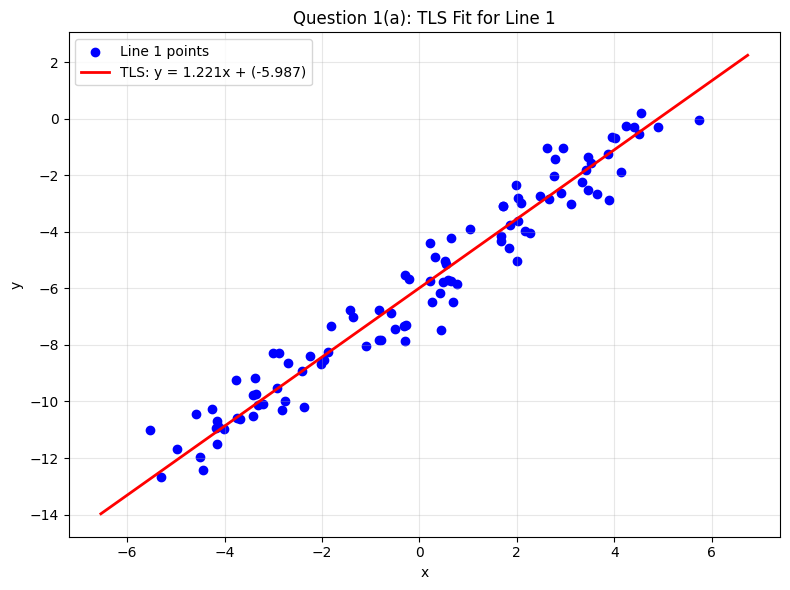


Plot saved as q1a_tls_line1.png


In [6]:
print("=" * 60)
print("Question 1(a): Total Least Squares — Line 1")
print("=" * 60)

x1 = D[:, 0]
y1 = D[:, 3]

a, b, c = fit_line_tls(x1, y1)

print(f"\nNumber of points: {len(x1)}")
print(f"\nLine parameters (ax + by + c = 0):")
print(f"  a = {a:.6f}")
print(f"  b = {b:.6f}")
print(f"  c = {c:.6f}")

if abs(b) > 1e-10:
    slope = -a / b
    intercept = -c / b
    print(f"\nSlope-intercept form: y = {slope:.6f}x + ({intercept:.6f})")

distances = np.abs(a * x1 + b * y1 + c)
print(f"\nMean orthogonal distance: {np.mean(distances):.6f}")
print(f"Sum of squared distances: {np.sum(distances**2):.6f}")

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, c='blue', label='Line 1 points')
x_range = np.linspace(np.min(x1) - 1, np.max(x1) + 1, 100)
if abs(b) > 1e-10:
    y_fit = slope * x_range + intercept
    plt.plot(x_range, y_fit, 'r-', linewidth=2, label=f'TLS: y = {slope:.3f}x + ({intercept:.3f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Question 1(a): TLS Fit for Line 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls_line1.png', dpi=150)
plt.show()
print("\nPlot saved as q1a_tls_line1.png")

Question 1 (b)


Question 1(b): RANSAC — Finding 3 Lines

Total points: 300

--- Line 1 ---
  Equation: -0.415789x + -0.909461y + 1.886151 = 0
  Slope-intercept: y = -0.457181x + (2.073921)
  Inliers: 106 points

--- Line 2 ---
  Equation: 0.765646x + -0.643263y + -3.838654 = 0
  Slope-intercept: y = 1.190253x + (-5.967475)
  Inliers: 80 points

--- Line 3 ---
  Equation: 0.733725x + -0.679446y + 0.744364 = 0
  Slope-intercept: y = 1.079887x + (1.095545)
  Inliers: 78 points


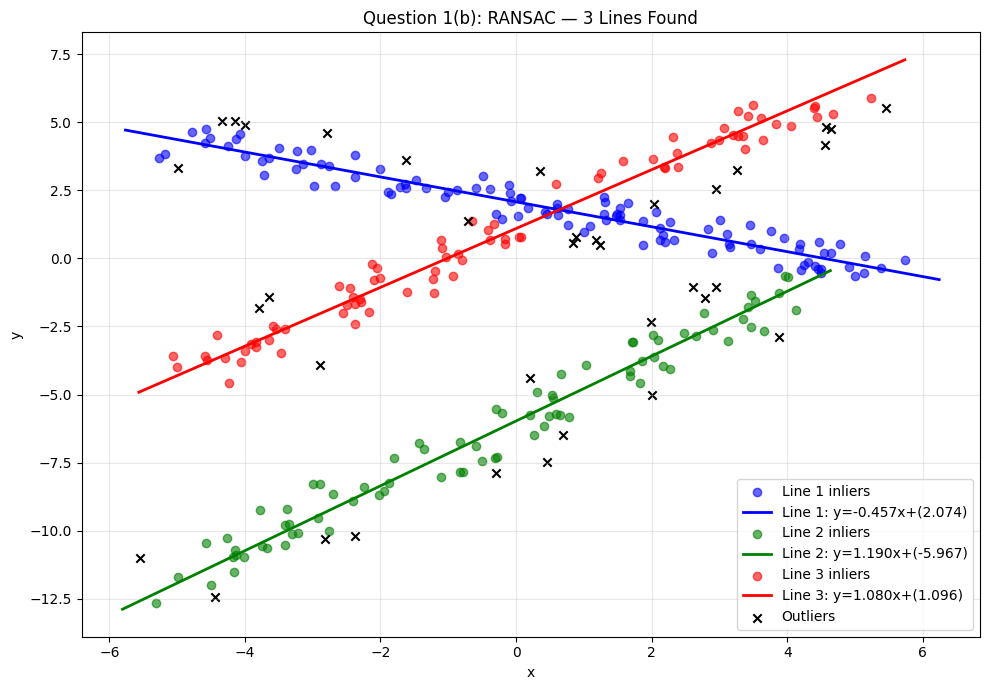


Plot saved as q1b_ransac_3lines.png


In [7]:
print("\n" + "=" * 60)
print("Question 1(b): RANSAC — Finding 3 Lines")
print("=" * 60)

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
print(f"\nTotal points: {len(X_all)}")


def ransac_line(X, Y, n_iter=5000, threshold=0.7):
    best_inliers = None
    best_count = 0
    best_params = None
    n = len(X)

    for _ in range(n_iter):
        idx = np.random.choice(n, 2, replace=False)
        x_s, y_s = X[idx], Y[idx]

        if np.allclose(x_s[0], x_s[1]) and np.allclose(y_s[0], y_s[1]):
            continue

        a, b, c = fit_line_tls(x_s, y_s)

        dists = np.abs(a * X + b * Y + c)

        inliers = dists < threshold
        count = np.sum(inliers)

        if count > best_count:
            best_count = count
            best_inliers = inliers.copy()
            best_params = (a, b, c)

    if best_inliers is not None and np.sum(best_inliers) >= 2:
        a, b, c = fit_line_tls(X[best_inliers], Y[best_inliers])
        best_params = (a, b, c)

    return best_params, best_inliers


np.random.seed(42)
remaining_mask = np.ones(len(X_all), dtype=bool)
lines_found = []
inlier_sets = []
colors_list = ['blue', 'green', 'red']

for line_num in range(1, 4):
    X_rem = X_all[remaining_mask]
    Y_rem = Y_all[remaining_mask]

    if len(X_rem) < 2:
        print(f"\nNot enough points for Line {line_num}")
        break

    params, inliers_local = ransac_line(X_rem, Y_rem, n_iter=5000, threshold=0.7)
    a, b, c = params

    print(f"\n--- Line {line_num} ---")
    print(f"  Equation: {a:.6f}x + {b:.6f}y + {c:.6f} = 0")
    if abs(b) > 1e-10:
        print(f"  Slope-intercept: y = {-a/b:.6f}x + ({-c/b:.6f})")
    print(f"  Inliers: {np.sum(inliers_local)} points")

    lines_found.append(params)
    rem_indices = np.where(remaining_mask)[0]
    inlier_global = rem_indices[inliers_local]
    inlier_sets.append(inlier_global)

    remaining_mask[inlier_global] = False

plt.figure(figsize=(10, 7))
for i, (params, inlier_idx) in enumerate(zip(lines_found, inlier_sets)):
    a, b, c = params
    xi = X_all[inlier_idx]
    yi = Y_all[inlier_idx]
    plt.scatter(xi, yi, c=colors_list[i], label=f'Line {i+1} inliers', alpha=0.6)

    x_range = np.linspace(np.min(xi) - 0.5, np.max(xi) + 0.5, 100)
    if abs(b) > 1e-10:
        y_fit = (-a * x_range - c) / b
        plt.plot(x_range, y_fit, color=colors_list[i], linewidth=2,
                 label=f'Line {i+1}: y={-a/b:.3f}x+({-c/b:.3f})')

if np.any(remaining_mask):
    plt.scatter(X_all[remaining_mask], Y_all[remaining_mask],
                c='black', marker='x', label='Outliers')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Question 1(b): RANSAC — 3 Lines Found')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac_3lines.png', dpi=150)
plt.show()
print("\nPlot saved as q1b_ransac_3lines.png")

Question 2

In [8]:
import cv2 as cv
import numpy as np

f = 8.0
pixel_size = 2.2e-3
u = 720.0

v = 1.0 / (1.0 / f - 1.0 / u)

print("=" * 60)
print("Question 2: Earring Size Estimation")
print("=" * 60)
print(f"\nCamera Parameters:")
print(f"  Focal length (f)     = {f} mm")
print(f"  Pixel size           = {pixel_size * 1000:.1f} µm = {pixel_size} mm")
print(f"  Object distance (u)  = {u} mm")

print(f"\nStep 1 — Image distance:")
print(f"  v = 1 / (1/f - 1/u)")
print(f"  v = 1 / (1/{f} - 1/{u})")
print(f"  v = {v:.4f} mm")

M = v / u
print(f"\nStep 2 — Magnification:")
print(f"  M = v / u = {v:.4f} / {u} = {M:.6f}")

scale = pixel_size / M
print(f"\nStep 3 — Scale factor:")
print(f"  1 pixel = pixel_size / M = {pixel_size} / {M:.6f}")
print(f"  1 pixel = {scale:.4f} mm in real world")
print(f"  1 pixel = {scale * 1000:.2f} µm in real world")

print(f"\n{'=' * 60}")
print("Step 4 — Measure from the image")
print("=" * 60)

img = cv.imread('earrings.jpg')

if img is not None:
    print(f"\nImage loaded: {img.shape[1]} x {img.shape[0]} pixels")

    print("\nClick on the top and bottom of each earring to measure diameter.")
    print("Press ESC when done.\n")

    click_points = []

    def mouse_callback(event, x, y, flags, param):
        if event == cv.EVENT_LBUTTONDOWN:
            click_points.append((x, y))
            cv.circle(param, (x, y), 3, (0, 0, 255), -1)
            if len(click_points) % 2 == 0:
                p1 = click_points[-2]
                p2 = click_points[-1]
                cv.line(param, p1, p2, (0, 255, 0), 2)
                dist_px = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
                actual_mm = dist_px * scale
                print(f"  Measurement: {dist_px:.1f} pixels = {actual_mm:.2f} mm = {actual_mm/10:.2f} cm")
                mid = ((p1[0] + p2[0]) // 2, (p1[1] + p2[1]) // 2)
                cv.putText(param, f"{actual_mm:.1f}mm", mid,
                           cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    img_display = img.copy()
    cv.namedWindow('Earrings - Click to measure', cv.WINDOW_AUTOSIZE)
    cv.setMouseCallback('Earrings - Click to measure', mouse_callback, img_display)

    print("Instructions: Click two points on each earring to measure its diameter.")
    print("Each pair of clicks computes the real-world size.")
    print("Press ESC to exit.\n")

    while True:
        cv.imshow('Earrings - Click to measure', img_display)
        key = cv.waitKey(20) & 0xFF
        if key == 27:
            break

    cv.destroyAllWindows()

    cv.imwrite('q2_earring_measured.jpg', img_display)
    print("\nAnnotated image saved as q2_earring_measured.jpg")

    print("\n--- Automatic estimation (Hough Circles) ---")
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_blur = cv.GaussianBlur(gray, (9, 9), 2)

    circles = cv.HoughCircles(
        gray_blur, cv.HOUGH_GRADIENT,
        dp=1.2, minDist=50,
        param1=100, param2=50,
        minRadius=30, maxRadius=300
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        img_circles = img.copy()
        for i, (cx, cy, r) in enumerate(circles[0, :]):
            diameter_px = 2 * r
            diameter_mm = diameter_px * scale
            print(f"  Circle {i+1}: center=({cx},{cy}), radius={r}px, "
                  f"diameter={diameter_px}px = {diameter_mm:.1f}mm = {diameter_mm/10:.1f}cm")
            cv.circle(img_circles, (cx, cy), r, (0, 255, 0), 2)
            cv.circle(img_circles, (cx, cy), 2, (0, 0, 255), 3)
            cv.putText(img_circles, f"{diameter_mm:.1f}mm",
                       (cx - 40, cy - r - 10),
                       cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
        cv.imwrite('q2_earring_circles.jpg', img_circles)
        print("\nCircle detection image saved as q2_earring_circles.jpg")
    else:
        print("  No circles detected automatically. Use manual measurement.")

else:
    print("\nImage not found. Using formula-based estimation:")
    
    print(f"\n  Formula: Actual size = P × {scale:.4f} mm")
    print(f"  where P = measured pixel diameter\n")
    for P in [100, 150, 200, 250, 300]:
        actual = P * scale
        print(f"  If P = {P:3d} pixels  →  actual = {actual:.1f} mm = {actual/10:.1f} cm")

print(f"\n{'=' * 60}")
print("Summary")
print("=" * 60)
print(f"  Image distance:   v = {v:.4f} mm")
print(f"  Magnification:    M = {M:.6f}")
print(f"  Scale factor:     1 pixel = {scale:.4f} mm")
print(f"  Actual size = pixel_count × {scale:.4f} mm")

Question 2: Earring Size Estimation

Camera Parameters:
  Focal length (f)     = 8.0 mm
  Pixel size           = 2.2 µm = 0.0022 mm
  Object distance (u)  = 720.0 mm

Step 1 — Image distance:
  v = 1 / (1/f - 1/u)
  v = 1 / (1/8.0 - 1/720.0)
  v = 8.0899 mm

Step 2 — Magnification:
  M = v / u = 8.0899 / 720.0 = 0.011236

Step 3 — Scale factor:
  1 pixel = pixel_size / M = 0.0022 / 0.011236
  1 pixel = 0.1958 mm in real world
  1 pixel = 195.80 µm in real world

Step 4 — Measure from the image

Image loaded: 1024 x 1024 pixels

Click on the top and bottom of each earring to measure diameter.
Press ESC when done.

Instructions: Click two points on each earring to measure its diameter.
Each pair of clicks computes the real-world size.
Press ESC to exit.

  Measurement: 123.5 pixels = 24.18 mm = 2.42 cm
  Measurement: 77.5 pixels = 15.17 mm = 1.52 cm
  Measurement: 129.5 pixels = 25.36 mm = 2.54 cm
  Measurement: 60.9 pixels = 11.92 mm = 1.19 cm
  Measurement: 116.2 pixels = 22.75 mm = 2.

KeyboardInterrupt: 

Question 3

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im1 = cv.imread('c1.jpg')
im2 = cv.imread('c2.jpg')
 
print(f"Image 1 shape: {im1.shape}")
print(f"Image 2 shape: {im2.shape}")

Image 1 shape: (2729, 2279, 3)
Image 2 shape: (2503, 2315, 3)


Question 3 (a)

Question 3(a): Manual Point Selection + Homography
Select 6 points on Image 1 (click in order). ESC to cancel.
  Point 1: (963, 750)
  Point 2: (1023, 611)
  Point 3: (1392, 664)
  Point 4: (1857, 536)
  Point 5: (1318, 1363)
  Point 6: (1535, 866)
Image 1 points:
[[ 963.  750.]
 [1023.  611.]
 [1392.  664.]
 [1857.  536.]
 [1318. 1363.]
 [1535.  866.]]

Select 6 corresponding points on Image 2 (same order). ESC to cancel.
  Point 1: (1145, 618)
  Point 2: (1241, 485)
  Point 3: (1592, 638)
  Point 4: (2059, 628)
  Point 5: (1311, 1270)
  Point 6: (1640, 848)
Image 2 points:
[[1145.  618.]
 [1241.  485.]
 [1592.  638.]
 [2059.  628.]
 [1311. 1270.]
 [1640.  848.]]

Homography (Manual):
[[ 2.37802717e+00  5.07761101e-01 -4.67809917e+02]
 [ 6.97642438e-01  2.45715514e+00 -1.32621833e+03]
 [ 3.32753144e-04  8.05423056e-04  1.00000000e+00]]


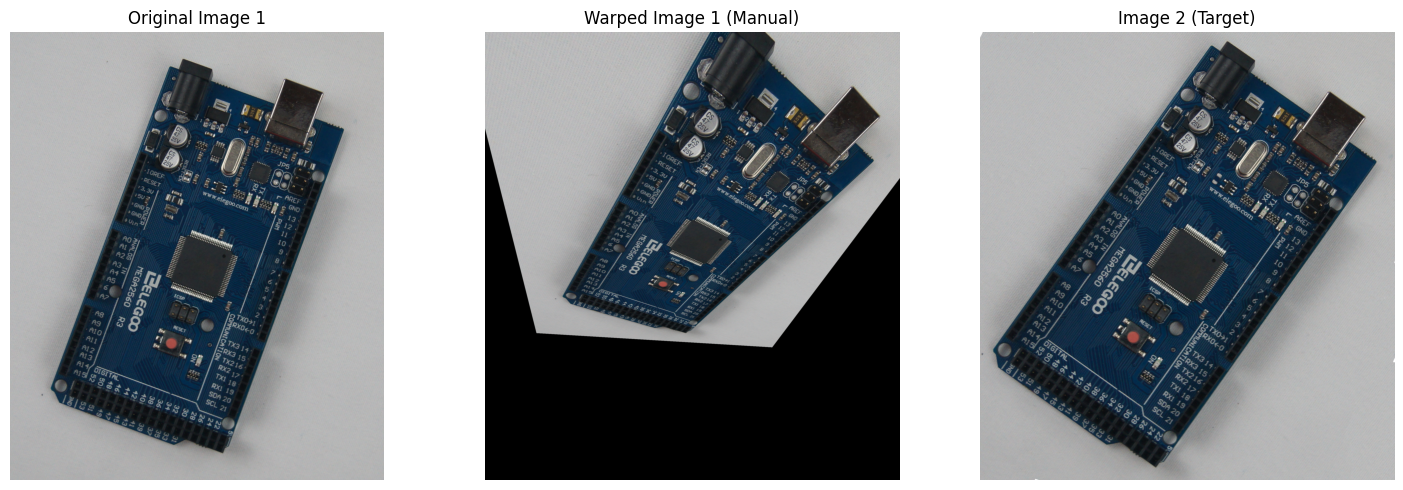

In [10]:
print("Question 3(a): Manual Point Selection + Homography")

N = 6
global n
n = 0
p1 = np.empty((N, 2))
p2 = np.empty((N, 2))


def draw_circle(event, x, y, flags, param):
    global n
    p = param[0]
    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(param[1], (x, y), 5, (255, 0, 0), -1)
        cv.putText(param[1], str(n + 1), (x + 8, y - 8),
                   cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        p[n] = (x, y)
        n += 1
        print(f"  Point {n}: ({x}, {y})")


print(f"Select {N} points on Image 1 (click in order). ESC to cancel.")
im1copy = im1.copy()
cv.namedWindow('Image 1 - Select Points', cv.WINDOW_AUTOSIZE)
cv.setMouseCallback('Image 1 - Select Points', draw_circle, [p1, im1copy])

while True:
    cv.imshow('Image 1 - Select Points', im1copy)
    if n == N or (cv.waitKey(20) & 0xFF == 27):
        break
cv.destroyAllWindows()
print(f"Image 1 points:\n{p1}")

print(f"\nSelect {N} corresponding points on Image 2 (same order). ESC to cancel.")
n = 0
im2copy = im2.copy()
cv.namedWindow('Image 2 - Select Points', cv.WINDOW_AUTOSIZE)
cv.setMouseCallback('Image 2 - Select Points', draw_circle, [p2, im2copy])

while True:
    cv.imshow('Image 2 - Select Points', im2copy)
    if n == N or (cv.waitKey(20) & 0xFF == 27):
        break
cv.destroyAllWindows()
print(f"Image 2 points:\n{p2}")

H_manual, _ = cv.findHomography(np.float32(p1), np.float32(p2), cv.RANSAC, 5.0)
print(f"\nHomography (Manual):\n{H_manual}")

h, w = im2.shape[:2]
warped_manual = cv.warpPerspective(im1, H_manual, (w, h))
cv.imwrite('q3a_warped_manual.jpg', warped_manual)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(im1, cv.COLOR_BGR2RGB))
plt.title('Original Image 1'); plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(warped_manual, cv.COLOR_BGR2RGB))
plt.title('Warped Image 1 (Manual)'); plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(im2, cv.COLOR_BGR2RGB))
plt.title('Image 2 (Target)'); plt.axis('off')
plt.tight_layout()
plt.savefig('q3a_comparison.png', dpi=150)
plt.show()

Question 3 (b)

In [ ]:
print("\n" + "=" * 60)
print("Question 3(b): Difference Image (Manual Homography)")
print("=" * 60)
 
diff_manual = cv.absdiff(warped_manual, im2)
diff_manual_gray = cv.cvtColor(diff_manual, cv.COLOR_BGR2GRAY)
_, diff_manual_thresh = cv.threshold(diff_manual_gray, 30, 255, cv.THRESH_BINARY)
 
cv.imwrite('q3b_diff_manual.jpg', diff_manual)
cv.imwrite('q3b_diff_manual_thresh.jpg', diff_manual_thresh)
print("Difference image saved as q3b_diff_manual.jpg")
print("Thresholded difference saved as q3b_diff_manual_thresh.jpg")
 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(diff_manual, cv.COLOR_BGR2RGB))
plt.title('Absolute Difference (Manual)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(diff_manual_thresh, cmap='gray')
plt.title('Thresholded Difference (Manual)')
plt.axis('off')
plt.tight_layout()
plt.savefig('q3b_diff_comparison.png', dpi=150)
plt.show()